# TIMEE: Time Series Classification via In-Context Learning

This notebook demonstrates TIMEE inference on a synthetic benchmark and a selection of
UCR datasets loaded via [aeon](https://www.aeon-toolkit.org/).

TIMEE classifies test series in a **single forward pass** using labeled training
examples — no per-dataset training or fine-tuning required.

In [1]:
# Uncomment to install dependencies
# !pip install timee-ts aeon matplotlib

import warnings

warnings.filterwarnings("ignore")

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from aeon.datasets import load_classification
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import accuracy_score, roc_auc_score

from timee import TimeeClassifier

## Model

The pretrained checkpoint is hosted on [HuggingFace](https://huggingface.co/liamsbhoo/timee)
and downloaded automatically on first use.

In [2]:
clf = TimeeClassifier.from_pretrained()

## Plotting helper

In [3]:
def plot_synthetic_episode(
    X0_ctx,
    X1_ctx,
    X0_qry,
    X1_qry,
    preds,
    y_test,
    title="",
    class_labels=("Class 0", "Class 1"),
    colors=("#08519C", "#DD8452"),
    patch_size=16,
):
    K = len(X0_ctx)
    T_len = X0_ctx.shape[1]

    # Build series list: (series, cls_idx, role, pred_or_None)
    series_list = []
    for i in range(K):
        series_list.append((X0_ctx[i], 0, f"Support {i+1}", None))
    for i in range(K):
        series_list.append((X1_ctx[i], 1, f"Support {i+1}", None))
    for i, pred in enumerate(preds[y_test == 0]):
        series_list.append((X0_qry[i], 0, "Query", int(pred)))
    for i, pred in enumerate(preds[y_test == 1]):
        series_list.append((X1_qry[i], 1, "Query", int(pred)))

    n_rows = len(series_list)
    patch_boundaries = np.arange(0, T_len + 1, patch_size)
    all_s = np.concatenate([X0_ctx, X1_ctx, X0_qry, X1_qry])
    y_lo, y_hi = all_s.min(), all_s.max()
    y_pad = (y_hi - y_lo) * 0.12

    fig = plt.figure(figsize=(9, n_rows * 0.52))
    gs = gridspec.GridSpec(n_rows, 1, hspace=0.01, figure=fig)
    first_ax = None

    for row, (series, cls_idx, role, pred) in enumerate(series_list):
        kw = {"sharex": first_ax, "sharey": first_ax} if first_ax else {}
        ax = fig.add_subplot(gs[row, 0], **kw)
        if first_ax is None:
            first_ax = ax

        c = colors[cls_idx]
        is_query = role == "Query"

        if is_query:
            ax.set_facecolor("#f5f5f5")

        ax.plot(np.arange(T_len), series, color=c, lw=2.0, alpha=0.9)
        for xb in patch_boundaries:
            ax.axvline(xb, color="gray", lw=1.0, ls=":")

        lbl = class_labels[cls_idx]
        annotation = role if is_query else f"{lbl}\n{role}"
        text_color = "#888888" if is_query else c
        ax.text(
            -0.02,
            0.5,
            annotation,
            transform=ax.transAxes,
            fontsize=9,
            color=text_color,
            ha="right",
            va="center",
            multialignment="right",
        )

        if is_query:
            correct = pred == cls_idx
            mc, sym = ("#2ca02c", "✓") if correct else ("#d62728", "✗")
            ax.text(
                1.01,
                0.5,
                f"→ C{pred} {sym}",
                transform=ax.transAxes,
                fontsize=9,
                color=mc,
                ha="left",
                va="center",
            )

        ax.xaxis.set_major_locator(MultipleLocator(patch_size))
        ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
        ax.yaxis.set_visible(False)
        plt.setp(ax.get_xticklabels(), visible=(row == n_rows - 1), rotation=45, ha="right")
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=10, y=1.03)
    fig.subplots_adjust(left=0.18, right=0.97)
    plt.show()

## Synthetic benchmark

A controlled two-class example with nearly identical signals — both classes share a
base frequency f₀, but differ in their second frequency (f₁ vs f₂):

- **Class 0** — sin(2π·f₀·t) + sin(2π·f₁·t) + noise
- **Class 1** — sin(2π·f₀·t) + sin(2π·f₂·t) + noise

Support rows are shown with a white background; query rows with a grey background.
Each query is annotated with the predicted class and a ✓/✗ marker.

In [4]:
T = 160  # divisible by patch_size=16 → 10 patches
K_SHOT = 3  # context examples per class
N_TEST = 2  # query examples per class
NOISE_STD = 0.5
FREQ_0 = 5
FREQ_1 = 13
FREQ_2 = 14

rng_synth = np.random.default_rng(0)
t = np.linspace(0, 1, T, endpoint=False)


def _make_signal(freq_extra=None):
    """Return a function that generates one sample with a random phase shift."""

    def _(phi):
        s = np.sin(2 * np.pi * FREQ_0 * t + phi)
        if freq_extra is not None:
            s = s + np.sin(2 * np.pi * freq_extra * t + phi)
        return s

    return _


def _noisy(make_signal, n):
    # phases = rng_synth.uniform(0, 2 * np.pi, n)
    phases = np.zeros(n)
    return np.array([make_signal(phi) + rng_synth.normal(0, NOISE_STD, T) for phi in phases])


X0_ctx = _noisy(_make_signal(FREQ_1), K_SHOT)
X1_ctx = _noisy(_make_signal(FREQ_2), K_SHOT)
X0_qry = _noisy(_make_signal(FREQ_1), N_TEST)
X1_qry = _noisy(_make_signal(FREQ_2), N_TEST)

X_train_synth = np.concatenate([X0_ctx, X1_ctx])[:, None, :]
y_train_synth = np.array([0] * K_SHOT + [1] * K_SHOT)
X_test_synth = np.concatenate([X0_qry, X1_qry])[:, None, :]
y_test_synth = np.array([0] * N_TEST + [1] * N_TEST)

preds_synth, _ = clf.predict(X_train_synth, y_train_synth, X_test_synth)
acc_synth = accuracy_score(y_test_synth, preds_synth)
roc_auc = roc_auc_score(y_test_synth, preds_synth)
print(
    f"Accuracy: {acc_synth:.0%}  ({int(acc_synth * len(y_test_synth))}/{len(y_test_synth)} correct)"
)
print(f"ROC AUC: {roc_auc:.3f}")

Accuracy: 100%  (4/4 correct)
ROC AUC: 1.000


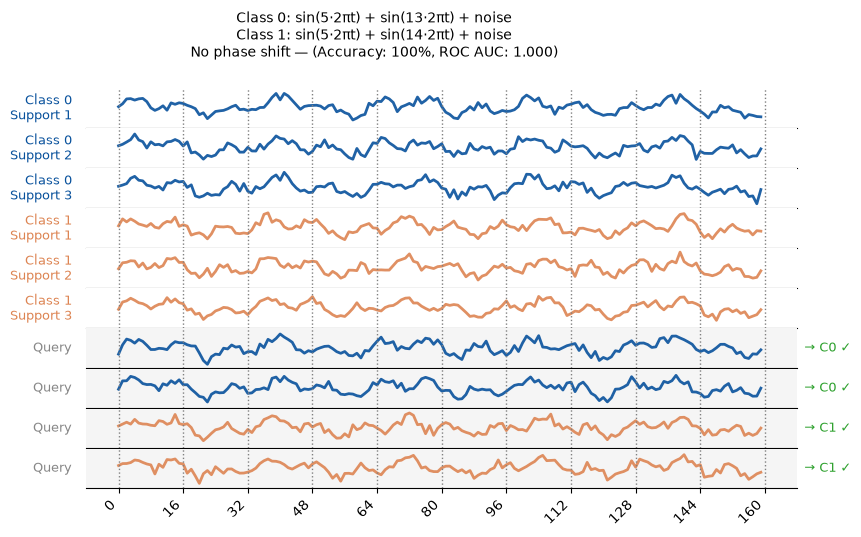

In [5]:
plot_synthetic_episode(
    X0_ctx,
    X1_ctx,
    X0_qry,
    X1_qry,
    preds_synth,
    y_test_synth,
    title=(
        f"Class 0: sin({FREQ_0}·2πt) + sin({FREQ_1}·2πt) + noise"
        f"\n"
        f"Class 1: sin({FREQ_0}·2πt) + sin({FREQ_2}·2πt) + noise\n"
        f"No phase shift — (Accuracy: {acc_synth:.0%}, ROC AUC: {roc_auc:.3f})"
    ),
)

The same signal types, but each sample now has a **random phase shift** — making the
classification harder since the waveforms no longer line up across support examples.

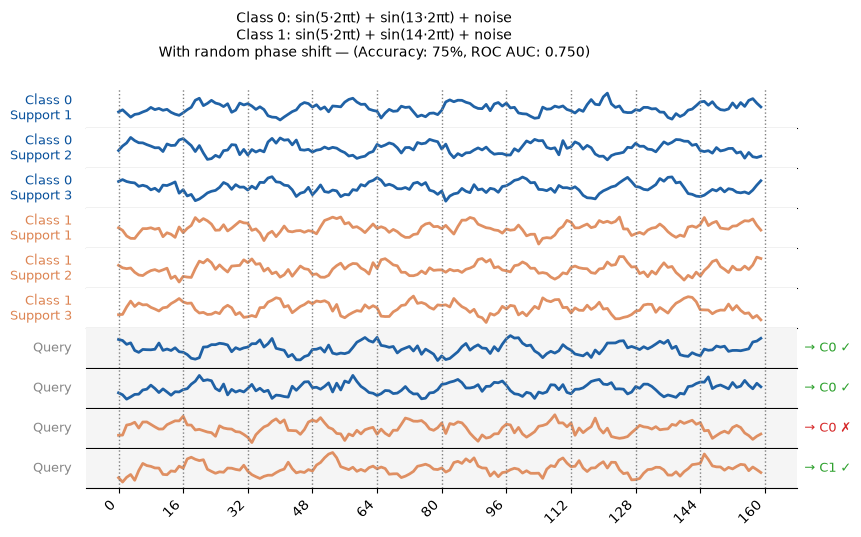

In [6]:
# Same signal types, random phase shift per sample
rng2 = np.random.default_rng(1)


def _noisy_shifted(make_signal, n):
    phases = rng2.uniform(0, 2 * np.pi, n)
    return np.array([make_signal(phi) + rng2.normal(0, NOISE_STD, T) for phi in phases])


X0_ctx2 = _noisy_shifted(_make_signal(FREQ_1), K_SHOT)
X1_ctx2 = _noisy_shifted(_make_signal(FREQ_2), K_SHOT)
X0_qry2 = _noisy_shifted(_make_signal(FREQ_1), N_TEST)
X1_qry2 = _noisy_shifted(_make_signal(FREQ_2), N_TEST)

X_train_synth2 = np.concatenate([X0_ctx2, X1_ctx2])[:, None, :]
y_train_synth2 = np.array([0] * K_SHOT + [1] * K_SHOT)
X_test_synth2 = np.concatenate([X0_qry2, X1_qry2])[:, None, :]
y_test_synth2 = np.array([0] * N_TEST + [1] * N_TEST)

preds_synth2, proba = clf.predict(X_train_synth2, y_train_synth2, X_test_synth2)
acc_synth2 = accuracy_score(y_test_synth2, preds_synth2)
roc_auc2 = roc_auc_score(y_test_synth2, preds_synth2)

plot_synthetic_episode(
    X0_ctx2,
    X1_ctx2,
    X0_qry2,
    X1_qry2,
    preds_synth2,
    y_test_synth2,
    title=(
        f"Class 0: sin({FREQ_0}·2πt) + sin({FREQ_1}·2πt) + noise"
        f"\n"
        f"Class 1: sin({FREQ_0}·2πt) + sin({FREQ_2}·2πt) + noise\n"
        f"With random phase shift — (Accuracy: {acc_synth2:.0%}, ROC AUC: {roc_auc2:.3f})"
    ),
)

## Real datasets

Evaluation on a selection of UCR benchmark datasets, loaded via `aeon`.

In [7]:
DATASETS = [
    "ArrowHead",
    "ECG5000",
    "GunPoint",
    "ItalyPowerDemand",
    "TwoPatterns",
]

results = []
for name in DATASETS:
    print(f"Evaluating {name}...")
    X_train, y_train = load_classification(name, split="train")
    X_test, y_test = load_classification(name, split="test")

    preds, probs = clf.predict(X_train, y_train, X_test)
    acc = accuracy_score(y_test, preds)
    classes = np.unique(y_train)
    n_classes = len(classes)
    if n_classes == 2:
        auc = roc_auc_score(y_test, probs[:, 1])
    else:
        auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro", labels=classes)

    results.append({"Dataset": name, "Classes": n_classes, "Accuracy": acc, "ROC AUC": auc})

Evaluating ArrowHead...
Evaluating ECG5000...
Evaluating GunPoint...
Evaluating ItalyPowerDemand...
Evaluating TwoPatterns...


In [8]:
col_w = 22
print(f"{'Dataset':<{col_w}}  {'Classes':>7}  {'Accuracy':>9}  {'ROC AUC':>8}")
print("-" * (col_w + 31))
for r in results:
    print(
        f"{r['Dataset']:<{col_w}}  {r['Classes']:>7}  {r['Accuracy']:>8.1%}  {r['ROC AUC']:>8.3f}"
    )

Dataset                 Classes   Accuracy   ROC AUC
-----------------------------------------------------
ArrowHead                     3     76.6%     0.964
ECG5000                       5     95.0%     0.952
GunPoint                      2     98.7%     0.997
ItalyPowerDemand              2     96.0%     0.993
TwoPatterns                   4     99.8%     1.000
